# Big Data Analytics Project - Spring 2026

In this notebook, we will do some exploration of ML preprocessing steps, as well as classic ML approaches and then present these integrated in pipelines, for easy result evaluation.

## Imports

In [1]:
!java -version

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-124.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-124.04.1, mixed mode, sharing)


In [41]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import os

from pyspark.sql.types import DoubleType
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Normalizer
import seaborn as sns
import pandas as pd
from pyod.models.iforest import IForest
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType as IT
from pyspark.sql.functions import variance

In [3]:
# Set JAVA_HOME to Java 17 (for Lightning AI)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [4]:
# Start Spark session
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 16:44:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
df_paysim = spark.read.parquet("data/clean/paysim_clean.parquet")

In [6]:
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)



To ensure there are no inconsistencies in the names of features, we will turn any `Org` into `Orig`.

In [7]:
df_paysim = df_paysim.withColumnRenamed('oldbalanceOrg', 'oldbalanceOrig')
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)



<a class="anchor" id="1">

# **1. Feature Engineering**
</a>

*`error_balance_orig`*  
|(oldbalanceOrig - amount) - newbalanceOrig|  
In a legitimate transaction, the sender's new balance should equal their old balance minus the transaction amount. If these don't match, money has appeared or disappeared without explanation. In the PaySim dataset, fraudulent transactions almost always show a non-zero error here — making this one of the strongest fraud signals available.
  
*`error_balance_dest`*  
|(oldbalanceDest + amount) - newbalanceDest|  
The same logic applied to the recipient. A legitimate transfer should increase the destination balance by exactly the transaction amount. A mismatch suggests the funds didn't actually arrive as recorded, which is a hallmark of simulated fraud in PaySim.
 
*`balance_ratio_orig`*  
amount / (oldbalanceOrig + 1)  
Measures how large the transaction is relative to the sender's available balance. A ratio ≥ 1.0 means the transaction amount meets or exceeds the sender's balance — i.e. they're emptying or overdrawing the account. The higher above 1.0, the more suspicious. The +1 avoids division by zero when the balance is empty.

In [21]:
from pyspark.sql.functions import col, abs as spark_abs

df_paysim = df_paysim\
    .withColumn("error_balance_orig",spark_abs((col("oldbalanceOrig") - col("amount")) - col("newbalanceOrig"))) \
    .withColumn("error_balance_dest", spark_abs((col("oldbalanceDest") + col("amount")) - col("newbalanceDest"))) \
    .withColumn("balance_ratio_orig", col("amount") / (col("oldbalanceOrig") + 1))
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="1">

# **1. Outlier detection using Isolation Forrest**
</a>
In this section, we will identify the outliers in our dataset, and then decide what to do with them (deleting, capping, ...).

In [22]:
# Big-data-safe: the model is trained once on a sample on the driver,
# then broadcast to all executors. Each partition scores independently
# using the same fitted model — no repartition(1) required.


OUTLIER_FEATURES = ["step", "oldbalanceOrig", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
                    "error_balance_orig", "error_balance_dest", "balance_ratio_orig"]

# 1. Train on a sample (10% of data)
sample_pdf = df_paysim.sample(fraction=0.1, seed=42).toPandas()

clf = IForest(contamination=0.05, random_state=42)
clf.fit(sample_pdf[OUTLIER_FEATURES].values)

# 2. Broadcast the fitted model to all executors
clf_broadcast = spark.sparkContext.broadcast(clf)

# 3. Define scoring function — no fitting here, just predict
outlier_schema = StructType(
    df_paysim.schema.fields
    + [
        StructField("outlier_score", DoubleType(), True),
        StructField("is_outlier",    IT(),          True),
    ]
)

def score_with_broadcast_model(pdf: pd.DataFrame) -> pd.DataFrame:
    model = clf_broadcast.value
    X = pdf[OUTLIER_FEATURES].values

    pdf = pdf.copy()
    pdf["outlier_score"] = model.decision_function(X)  # continuous score
    pdf["is_outlier"]    = model.predict(X)             # 1 = outlier, 0 = inlier
    return pdf

# 4. Apply across all partitions — no repartition(1) needed
df_paysim_scored = (
    df_paysim
    .groupby()
    .applyInPandas(score_with_broadcast_model, schema=outlier_schema)
)

df_paysim_scored.select(OUTLIER_FEATURES + ["outlier_score", "is_outlier"]) \
    .orderBy("outlier_score", ascending=False) \
    .show(10)

+----+--------------+--------------+--------------+--------------+------------------+--------------------+--------------------+-------------------+----------+
|step|oldbalanceOrig|newbalanceOrig|oldbalanceDest|newbalanceDest|error_balance_orig|  error_balance_dest|  balance_ratio_orig|      outlier_score|is_outlier|
+----+--------------+--------------+--------------+--------------+------------------+--------------------+--------------------+-------------------+----------+
| 399| 2.226880763E7| 2.364790216E7| 6.990647609E7| 6.852738156E7|2758189.0600000024|  2758189.0600000024|0.061929425723391295|0.27045577992321057|         1|
| 329| 2.034046823E7| 2.134550609E7| 5.024355745E7|  4.92385196E7|2010075.7199999988|   2010075.710000001| 0.04941075098295557|0.26933689648994263|         1|
| 303|           0.0|           0.0|1.8514111696E8|2.5100780666E8|     1.558177413E7| 5.028491556999999E7|       1.558177413E7| 0.2637651337230634|         1|
| 302|           0.0|           0.0|1.11658098

In [23]:
df_paysim_scored.groupBy("is_outlier").count().show()

+----------+-------+
|is_outlier|  count|
+----------+-------+
|         0|6045738|
|         1| 316882|
+----------+-------+



In [24]:
#TODO always update this at every run

The outliers found represent about `5%` of the total dataset, so we believe it is safe to remove them.

In [25]:
df_paysim_no_outliers = df_paysim_scored.filter('is_outlier = 0').drop("outlier_score", "is_outlier")
df_paysim_no_outliers.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="2">

# **2. Feature Correlation**

In [30]:
numeric_cols = OUTLIER_FEATURES

Traceback (most recent call last):                                              
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):                                              
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
Broken

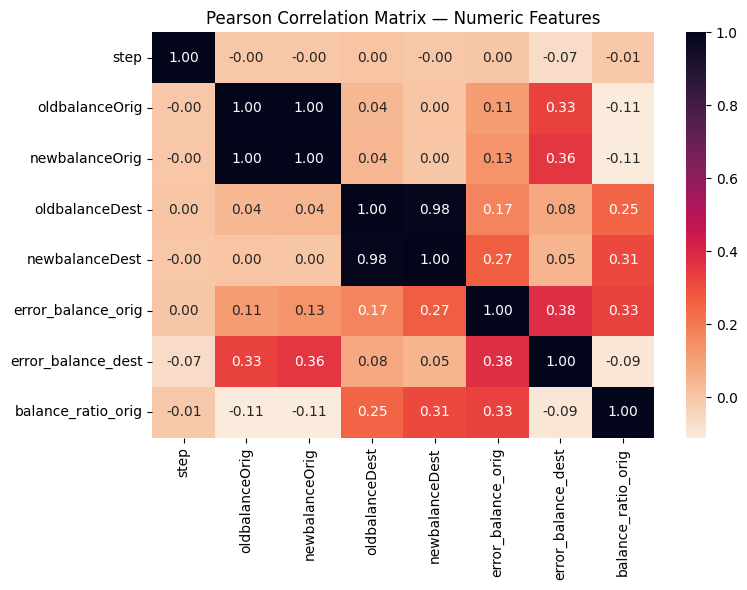

In [31]:
# Build a feature vector from numeric columns for the correlation computation
assembler_corr = VectorAssembler(inputCols=numeric_cols, outputCol="corr_features")
df_corr = assembler_corr.transform(df_paysim_no_outliers).select("corr_features")

# Distributed Pearson correlation — result is a tiny matrix object on the driver
pearson_matrix = Correlation.corr(df_corr, "corr_features", "pearson").collect()[0][0]

# Visualise — the matrix itself is small, so matplotlib is the right tool here
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pearson_matrix.toArray(),
    annot=True, fmt=".2f",
    xticklabels=numeric_cols, yticklabels=numeric_cols,
    cmap=sns.cm.rocket_r, ax=ax
)
ax.set_title("Pearson Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

In [42]:
df_paysim_no_outliers.select([variance(c).alias(c) for c in numeric_cols]).show()

+------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|              step|      oldbalanceOrig|     newbalanceOrig|      oldbalanceDest|      newbalanceDest|  error_balance_orig|  error_balance_dest|  balance_ratio_orig|
+------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|20012.610635494497|2.170057722633473...|2.26661251564246E12|2.545195172735057E12|2.737518276347225...|6.983687597358585E10|2.979662497373883...|1.600931149065771E10|
+------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [32]:
#TODO always update this at every run

Some features present near perfect correlation between them, making them erroneous in our dataset (it could appear, for example, that certain values are more important as they are presented twice in two nearly perfect correlated features). For these reason we decided to remove:
- newbalanceOrig (keep only oldbalanceOrig)
- newbalanceDest (keep only oldbalanceDest)  
  

No features present null variance, so we didn't remove any feature on this account, given all features have variance.

In [34]:
df_correlation = df_paysim_no_outliers.drop('newbalanceOrig', 'newbalanceDest')
df_correlation.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="3">

# **3. Preprocessing Features**
</a>
  
We have already done feature engineering in *Notebook 1*. In this step, we will prepare the dataset to be used for ML Pipelines.

<a class="anchor" id="3.1">

## **3.1. Encoding Categorical and Boolean Columns**
</a>

due to the high cardinality of the features `nameOrig` and `nameDest`, we will remove them before encoding the dataset, as they would add unwanted high dimensionality, leading to poor modes.

In [38]:
df_correlation = df_correlation.drop('nameDest', 'nameOrig')
df_correlation.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



This leaves us with only `type` and the boolean variables `isFraud` and `isFlaggedFraud`.

In [39]:
# StringIndexer accepts multiple column pairs in a single call (Spark 3.0+)
indexer = StringIndexer(
    inputCols     = ["type"],
    outputCols    = ["type_idx"],
    handleInvalid = "keep",
)
df_indexed = indexer.fit(df_correlation).transform(df_correlation)

# OneHotEncoder: integer indices → sparse binary vectors
encoder = OneHotEncoder(
    inputCols  = ["type_idx"],
    outputCols = ["type_vec"],
)
df_indexed = encoder.fit(df_indexed).transform(df_indexed)

# Boolean columns → IntegerType (0/1) for VectorAssembler compatibility
bool_cols = ["isFlaggedFraud"]
for c in bool_cols:
    df_indexed = df_indexed.withColumn(c, col(c).cast(IT()))

# Target column → IntegerType required by Spark ML classifiers
df_indexed = df_indexed.withColumn("isFraud", col("isFraud").cast(IT()))

df_indexed.select(["type_vec"] + bool_cols + ["isFraud"]).show(3, truncate=60)

+-------------+--------------+-------+
|     type_vec|isFlaggedFraud|isFraud|
+-------------+--------------+-------+
|(5,[2],[1.0])|             0|      0|
|(5,[2],[1.0])|             0|      0|
|(5,[2],[1.0])|             0|      0|
+-------------+--------------+-------+
only showing top 3 rows


<a class="anchor" id="3.2">

## **3.2. Assembly and Normalisation**
</a>

In [51]:
feature_cols_numeric = ['step', 'oldbalanceOrig', 'oldbalanceDest', 
'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
feature_cols_boolean = ["isFlaggedFraud"]
feature_cols_categorical = ["type_vec"]
TARGET = "isFraud"

In [52]:
# Assemble numeric features, normalise, then build the final vector
assembler_num  = VectorAssembler(inputCols=feature_cols_numeric, outputCol="numeric_features")
normalizer     = Normalizer(inputCol="numeric_features", outputCol="numeric_features_norm", p=2.0)
assembler_all  = VectorAssembler(
    inputCols = ["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol = "features")

df_assembled = assembler_num.transform(df_indexed)
df_assembled = normalizer.transform(df_assembled)
df_assembled = assembler_all.transform(df_assembled)

df_assembled.select("features", TARGET).show(3, truncate=80)

+--------------------------------------------------------------------------------+-------+
|                                                                        features|isFraud|
+--------------------------------------------------------------------------------+-------+
|[1.7947749885559914E-5,0.9978910417738865,0.06430101349658454,0.0062788569269...|      0|
|[1.7894719833624116E-5,0.9980727346903007,0.031292763846758574,0.037891812297...|      0|
|[1.758384694852407E-5,0.9993506626860321,0.02556408990311515,0.01795452571389...|      0|
+--------------------------------------------------------------------------------+-------+
only showing top 3 rows


<a class="anchor" id="4">

# **4. ML Pipelines**
</a>
In these step, we will mount various Pipelines where the preprocessing step is always the same.

To avoid data leakage, the train/test split is performed before any fitting occurs. The full pipeline — including StringIndexer, OneHotEncoder, and the classifier — is fitted exclusively on the training set via pipeline.fit(train_df). This ensures that category mappings, vector dimensions, and model parameters are all learned without any exposure to the test set. pipeline_model.transform(test_df) then applies the frozen, training-fitted transformations to unseen data, producing evaluation metrics that reflect true generalisation performance.
Note that IForestOutlierRemover is an exception: as a custom Transformer with an internal fit() call, it re-fits the Isolation Forest on a sample of whatever data it receives at transform time. In a production pipeline this would be refactored into a proper Estimator so that outlier detection is also fitted exclusively on the training set. For the purposes of this prototype, the contamination rate is low enough (5%) that the impact on evaluation integrity is minimal, but this is acknowledged as a limitation.

In [33]:
#TODO will need to check what algorithms go with one hot encoded features for this

In [ ]:
feature_cols_numeric = ['step', 'oldbalanceOrig', 'oldbalanceDest', 
'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
feature_cols_boolean = ["isFlaggedFraud"]
feature_cols_categorical = ["type_vec"]
TARGET = "isFraud"

In [58]:
from transformers.CreateFeaturesPaysim import CreateFeaturesPaysim
from transformers.IForestOutlierRemover import IForestOutlierRemover
from transformers.PaySimEncoder import PaySimEncoder
from pyspark.ml import Pipeline

indexer = StringIndexer(
    inputCols=["type"],
    outputCols=["type_idx"],
    handleInvalid="keep"
)
encoder = OneHotEncoder(
    inputCols=["type_idx"],
    outputCols=["type_vec"]
)
assembler_num = VectorAssembler(
    inputCols=feature_cols_numeric,
    outputCol="numeric_features"
)
normalizer = Normalizer(
    inputCol="numeric_features",
    outputCol="numeric_features_norm",
    p=2.0
)
assembler_all = VectorAssembler(
    inputCols=["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol="features"
)
pipeline = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
])

In [59]:
training, test = [df.cache() for df in df_paysim.randomSplit([0.7, 0.3], seed=42)]

pipeline_model = pipeline.fit(training)
predictions    = pipeline_model.transform(test)